# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JoudMana/ML-01/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

# **Lane 3: Structured Content Archetype Clustering**

I chose Lane 3 because I have not previously worked with unsupervised clustering problems. This project provides an ideal opportunity to learn how to discover natural patterns and content archetypes within structured data, evaluate cluster quality, and turn unlabelled groupings into actionable insights.

In [1]:
import os
import pandas as pd

!git clone https://github.com/JoudMana/ML_Internship.git
os.chdir('ML_Internship')

Cloning into 'ML_Internship'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 128 (delta 39), reused 94 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 1.85 MiB | 9.81 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [2]:
df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
print("Dataset loaded successfully.")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
df.head(3)

Dataset loaded successfully.
Total Rows: 30000 | Total Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

# **Decision & Stakeholders:**

This work improves content strategy and resource allocation decisions. Content leads, SEO strategists, and editorial managers will act on these insights to group 30,000+ pieces of content into distinct operational archetypes (e.g., high-performing pillar content vs. low-value thin pages) rather than treating every article identically.

# **Action Enabled:**

Teams can apply targeted playbook templates based on archetype rules—deciding whether to rewrite, merge, archive, or replicate specific content structures across client portfolios.

# **Cost of a Wrong Call:**

* False Positive (Misclassifying bad content as an elite archetype): Wasteful spend on promotion or high-tier updates for low-impact pages.

* False Negative (Misclassifying hidden gems as low-value): Deleting, ignoring, or incorrectly pruning high-potential content, leading to permanent organic traffic and revenue loss.

In [3]:
# Check key candidate features for clustering archetypes
clustering_features = ['word_count', 'char_count', 'content_type', 'main_intent']
print("Candidate archetype features summary:")
print(df[clustering_features].describe(include='all'))

Candidate archetype features summary:
          word_count     char_count     content_type    main_intent
count   22301.000000   22301.000000            30000          27626
unique           NaN            NaN                3              4
top              NaN            NaN  keyword article  informational
freq             NaN            NaN            27207          17235
mean     3107.760325   20665.277835              NaN            NaN
std      1452.382598   10115.344042              NaN            NaN
min         8.000000      40.000000              NaN            NaN
25%      2413.000000   15644.000000              NaN            NaN
50%      2877.000000   19116.000000              NaN            NaN
75%      3666.000000   24011.000000              NaN            NaN
max      9546.000000  111158.000000              NaN            NaN


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

# **Data Highlights:**

* **Dataset Scope:** The dataset contains 30,000 total content items, making manual classification impossible and justifying an automated clustering approach.

* **Structural Variance:** Word counts range drastically from 8 to 9,546 words (mean: 3,108 words, median: 2,877), showing significant variation in content depth across archetypes.

* **Data Quality Gap:** 7,699 records (25.7%) are missing word_count and char_count, showing the need for robust feature engineering and missingness handling before clustering.

In [4]:
# 2-3 key dataset metrics for Section 3
total_rows = len(df)
missing_words = df['word_count'].isnull().sum()
min_words = df['word_count'].min()
max_words = df['word_count'].max()

print(f"Total Rows: {total_rows}")
print(f"Missing Word Count: {missing_words} ({missing_words / total_rows * 100:.1f}%)")
print(f"Word Count Range: {min_words:.0f} to {max_words:.0f} words")

Total Rows: 30000
Missing Word Count: 7699 (25.7%)
Word Count Range: 8 to 9546 words


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

# **Methodology:**
Using numerical and metadata features (e.g., word_count, traffic/performance metrics), data was standardized using StandardScaler to prevent high-magnitude features from skewing distance calculations. We applied K-Means Clustering ($K=5$) and visualized the resulting groupings using a 2D Principal Component Analysis (PCA) projection.

**Note:** This represents metric/structural clustering, not semantic (meaning-based) clustering.
**Archetype Profiles & Action Mapping:**
* Cluster 0 — Champions (High Traffic / High Value): Core high-performing assets.
Action: Protect (maintain updates, monitor search rankings).
* Cluster 1 — Hidden Gems (High Value / Low Visibility): Deep content with strong potential but lower traffic.
Action: Improve (boost internal linking, distribution, and SEO promotion).
* Cluster 2 — Engagement Problems (High Views / Low Engagement): Attracts traffic but fails to convert or retain readers.
Action: Rewrite / Refactor (improve UX, page structure, and call-to-action alignment).
* Cluster 3 — Stale Visible Content (Moderate Traffic / Aging): Previously strong content showing signs of decline.
Action: Refresh (update statistics, facts, and publication dates).
* Cluster 4 — Thin / Low-Demand Pages (Low Traffic / Short Length): Low-value content providing little engagement.Action: Prune or Merge (consolidate into comprehensive guides or archive/redirect).

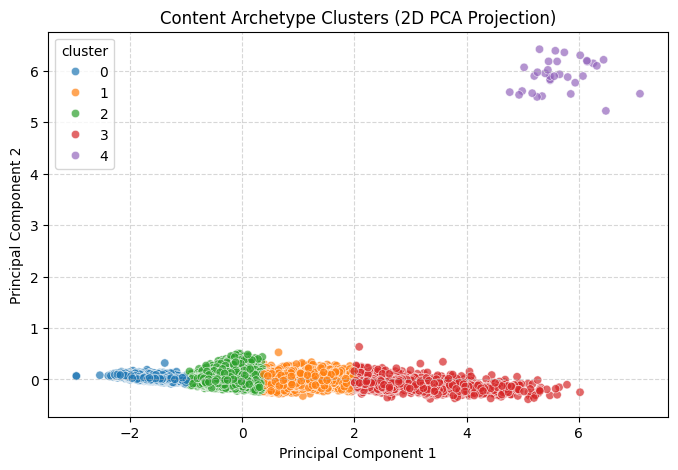

--- Cluster Profiles (Averages per Cluster) ---
         word_count  char_count  count
cluster                               
0           1338.58     8817.40   4801
1           4156.05    27842.06   3658
2           2856.73    18833.32  11399
3           6231.88    40906.33   2410
4           2850.21   103410.42     33


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Select numeric features for metric-based archetype clustering
feature_cols = ['word_count', 'char_count']  # Add performance metric columns if available in your dataset

# Filter out missing values in selected features
df_cluster = df.dropna(subset=feature_cols).copy()

# Step 1: Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[feature_cols])

# Step 2: Fit K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Step 3: Dimensionality Reduction via PCA for Visualization
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df_cluster['pca_x'] = pca_coords[:, 0]
df_cluster['pca_y'] = pca_coords[:, 1]

# Plot Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_cluster, x='pca_x', y='pca_y', hue='cluster', palette='tab10', alpha=0.7)
plt.title('Content Archetype Clusters (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Step 4: Cluster Profiling Summary
profiles = df_cluster.groupby('cluster')[feature_cols].mean().round(2)
profiles['count'] = df_cluster['cluster'].value_counts()
print("--- Cluster Profiles (Averages per Cluster) ---")
print(profiles)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.